In [26]:
#NFL Skill Position Aging Curves — Modeling Notebook
#Fits mixed-effects models per position using EPA z-score as a unified cross-position metric

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

#Position setup
pos_order  = ["RB", "WR", "TE", "QB"]
pos_colors = {"RB": "#1D9E75", "WR": "#3B8BD4", "TE": "#E8593C", "QB": "#9B59B6"}

In [27]:
#Load data from database
conn = sqlite3.connect("../db/nfl_skill_positions.db")
df = pd.read_sql_query("""
    SELECT s.*, p.display_name
    FROM season_stats s
    JOIN players p ON s.player_id = p.player_id
""", conn)
conn.close()

#Cap at 35 for modeling to limit survivorship bias tail while keeping legitimate veteran careers
df = df[df["age"] <= 35].copy()

# Get position-specific EPA column
def get_epa_col(position):
    if position == "QB":
        return "passing_epa"
    elif position == "RB":
        return "rushing_epa"
    else:
        return "receiving_epa"

df["epa_raw"] = df.apply(lambda row: row[get_epa_col(row["position"])], axis=1)

#Standardize EPA within position
#Z-score makes cross-position comparison valid by measuring each player relative to peers at their position
df["epa_z"] = df.groupby("position")["epa_raw"].transform(
    lambda x: (x - x.mean()) / x.std()
)

#Center age within each position separately
def center_age(group):
    group["age_c"]  = group["age"] - group["age"].mean()
    group["age_c2"] = group["age_c"] ** 2
    return group

df = df.groupby("position", group_keys=False).apply(center_age)

#Store position mean ages for unscaling peak age later
pos_mean_age = df.groupby("position")["age"].mean()

print(f"Dataset ready: {len(df)} rows")
print(f"\nRows per position:")
for pos in pos_order:
    print(f"  {pos}: {len(df[df['position'] == pos])}")
print(f"\nMean age by position:")
print(pos_mean_age.round(1))

Dataset ready: 5480 rows

Rows per position:
  RB: 1611
  WR: 2095
  TE: 1025
  QB: 749

Mean age by position:
position
QB    27.7
RB    25.8
TE    26.7
WR    26.4
Name: age, dtype: float64


In [28]:
#Fit mixed-effects model per position
#Formula: epa_z ~ age_c + age_c2 + (1 | player_id)
#Fixed effects: age + age squared (quadratic aging curve)
#Random effect: player intercept (accounts for talent differences)

results   = {}
peak_ages = {}

for pos in pos_order:
    pos_df = df[df["position"] == pos].copy()

    model  = smf.mixedlm(
        "epa_z ~ age_c + age_c2",
        data=pos_df,
        groups=pos_df["player_id"]
    )
    result = model.fit(reml=True)
    results[pos] = result

    b1 = result.fe_params["age_c"]
    b2 = result.fe_params["age_c2"]

    #Peak age only valid if curvature is negative, significant, and large enough to be meaningful
    if b2 < 0 and result.pvalues["age_c2"] < 0.05:
        peak_age_c    = -b1 / (2 * b2)
        peak_age      = peak_age_c + pos_mean_age[pos]
        peak_ages[pos] = round(peak_age, 1)
        peak_str      = f"{peak_age:.1f} years"
    else:
        peak_ages[pos] = None
        peak_str       = "No clear peak (monotonic trend)"

    print(f"{pos}:")
    print(f"  Converged:     {result.converged}")
    print(f"  Age (linear):  {b1:.4f}   p={result.pvalues['age_c']:.3f}")
    print(f"  Age (squared): {b2:.4f}   p={result.pvalues['age_c2']:.3f}")
    print(f"  Peak age:      {peak_str}")
    print()

print("Peak ages summary:")
for pos in pos_order:
    peak = peak_ages[pos] if peak_ages[pos] else "No clear peak"
    print(f"  {pos}: {peak}")

RB:
  Converged:     True
  Age (linear):  -0.0312   p=0.002
  Age (squared): 0.0034   p=0.180
  Peak age:      No clear peak (monotonic trend)

WR:
  Converged:     True
  Age (linear):  0.0074   p=0.351
  Age (squared): -0.0062   p=0.000
  Peak age:      27.0 years

TE:
  Converged:     True
  Age (linear):  -0.0322   p=0.002
  Age (squared): -0.0084   p=0.001
  Peak age:      24.8 years

QB:
  Converged:     True
  Age (linear):  0.0529   p=0.000
  Age (squared): -0.0123   p=0.000
  Peak age:      29.9 years

Peak ages summary:
  RB: No clear peak
  WR: 27.0
  TE: 24.8
  QB: 29.9


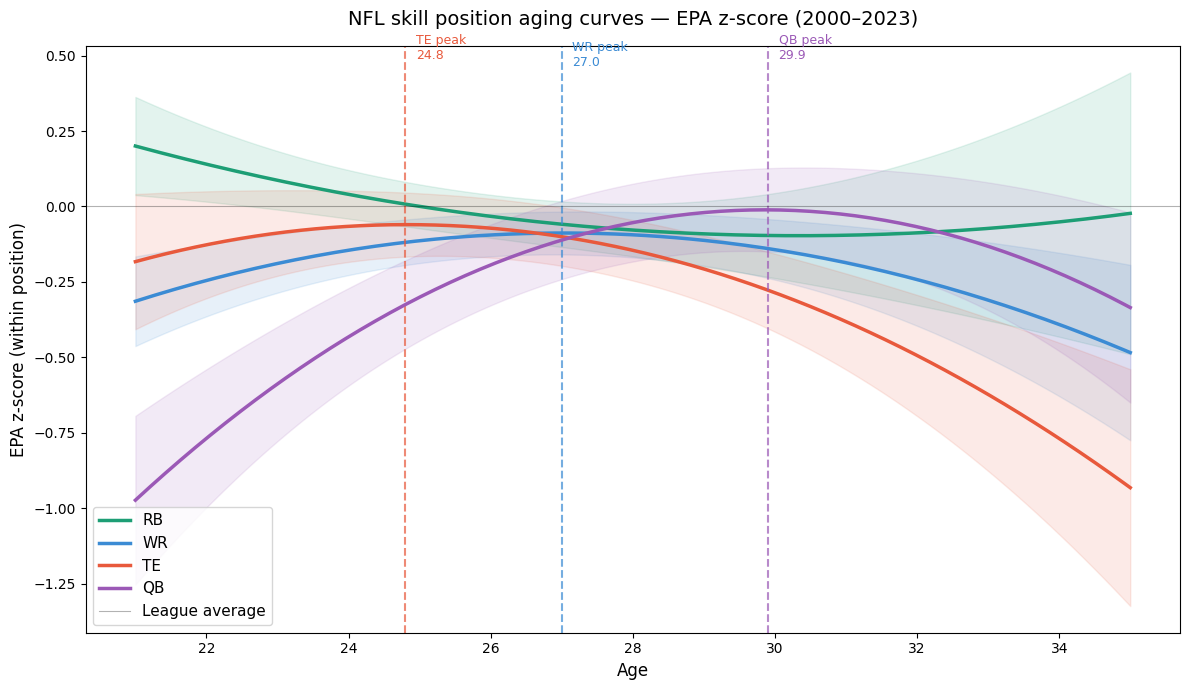

In [29]:
#all four position aging curves on one plot
fig, ax = plt.subplots(figsize=(12, 7))

age_range_full = np.linspace(21, 35, 200)

for pos in pos_order:
    pos_df  = df[df["position"] == pos]
    result  = results[pos]
    b1      = result.fe_params["age_c"]
    b2      = result.fe_params["age_c2"]
    intercept = result.fe_params["Intercept"]

    age_range_c  = age_range_full - pos_mean_age[pos]
    age_range_c2 = age_range_c ** 2
    predicted    = intercept + b1 * age_range_c + b2 * age_range_c2

    #Confidence interval
    se = np.sqrt(
        result.cov_params().loc["Intercept", "Intercept"] +
        age_range_c**2  * result.cov_params().loc["age_c",  "age_c"] +
        age_range_c2**2 * result.cov_params().loc["age_c2", "age_c2"]
    )
    ci_upper = predicted + 1.96 * se
    ci_lower = predicted - 1.96 * se

    ax.plot(age_range_full, predicted,
            color=pos_colors[pos], linewidth=2.5, label=pos)
    ax.fill_between(age_range_full, ci_lower, ci_upper,
                    alpha=0.12, color=pos_colors[pos])

    #Add peak age line for positions with clear peak
    if peak_ages[pos]:
        ax.axvline(peak_ages[pos], color=pos_colors[pos],
                   linestyle="--", linewidth=1.5, alpha=0.7)
        ax.text(peak_ages[pos] + 0.15, ax.get_ylim()[1] * 0.92,
                f"{pos} peak\n{peak_ages[pos]}",
                color=pos_colors[pos], fontsize=9)

ax.axhline(0, color="black", linestyle="-",
           linewidth=0.8, alpha=0.3, label="League average")
ax.set_title("NFL skill position aging curves — EPA z-score (2000–2023)",
             fontsize=14, pad=15)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("EPA z-score (within position)", fontsize=12)
ax.legend(fontsize=11, loc="lower left")

plt.tight_layout()
plt.show()

In [31]:
#chart for README
fig.savefig("aging_curve_comparison.png", dpi=150, bbox_inches="tight")